In [ ]:
import math
import numpy as np
import scipy.integrate as integrate
from scipy.special import gamma
import matplotlib.pyplot as plt

def prior(alpha, beta, theta):

    return gamma(alpha+beta)/gamma(alpha)/gamma(beta) * theta**(alpha-1) * (1-theta)**(beta-1)

def likelihood(n, h, theta):

    return math.comb(n, h) * theta**h * (1-theta)**(n-h)

In [145]:
def posterior(alpha, beta, n, h):

    def product(theta):
        return prior(alpha, beta, theta) * likelihood(n, h, theta)
    
    post_arr = []
    theta_arr = np.linspace(0, 1,1000)

    for theta in theta_arr:
        post_arr.append(product(theta))

    post_arr = np.array(post_arr)
    
    norm,_ = integrate.quad(product, 0, 1)

    plt.plot(theta_arr, post_arr / norm, label=f'n = {n}, h = {h}')
    plt.xlabel(r'$\theta$')
    plt.ylabel('Probability Density')
    plt.legend()

    return theta_arr, post_arr/norm


(array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
        0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
        0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
        0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
        0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
        0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
        0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
        0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
        0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
        0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
        0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
        0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
        0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
        0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
        0.07007007, 0.07107107, 0.07207207, 0.07

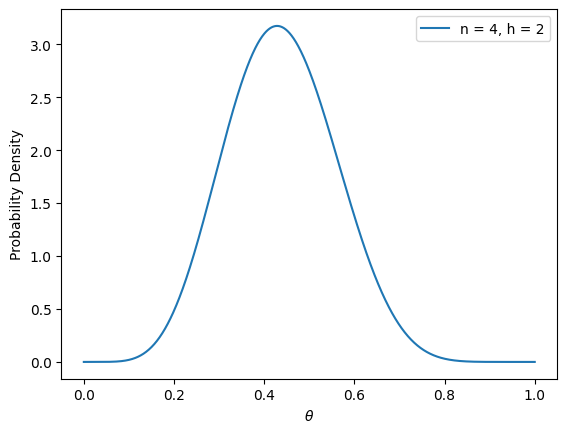

In [146]:
posterior(5,7,4,2)

(array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
        0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
        0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
        0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
        0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
        0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
        0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
        0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
        0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
        0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
        0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
        0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
        0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
        0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
        0.07007007, 0.07107107, 0.07207207, 0.07

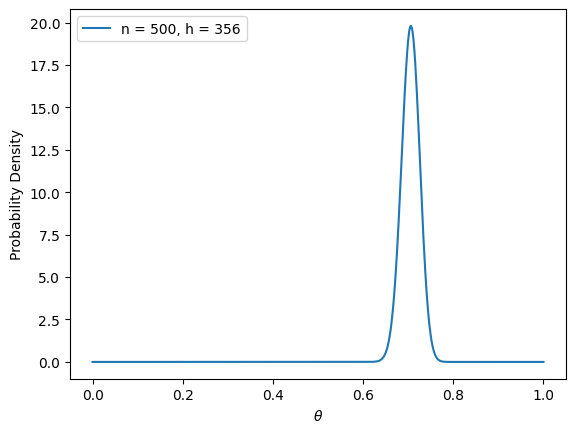

In [147]:
data = np.loadtxt('HW06_data.txt')
n = len(data)
h = np.sum(data).astype(int)

posterior(5,7,n,h)

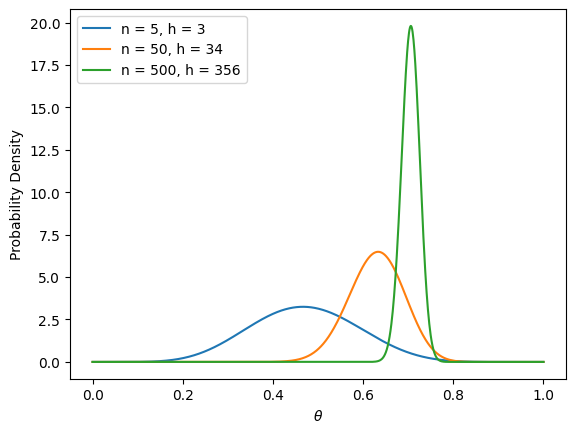

In [148]:
n_arr = [5, 50, 500]

for n in n_arr:
    h = np.sum(data[:n]).astype(int)
    posterior(5,7,n,h)

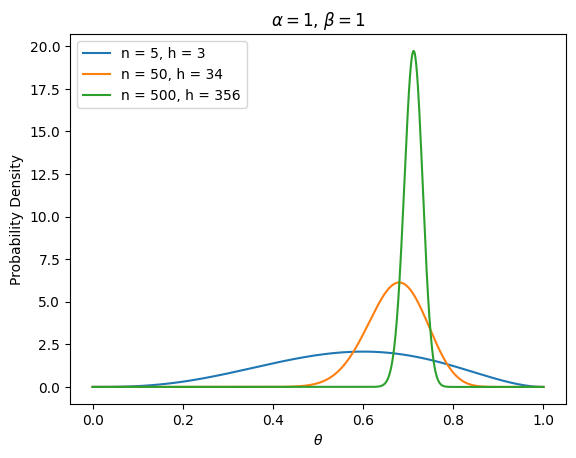

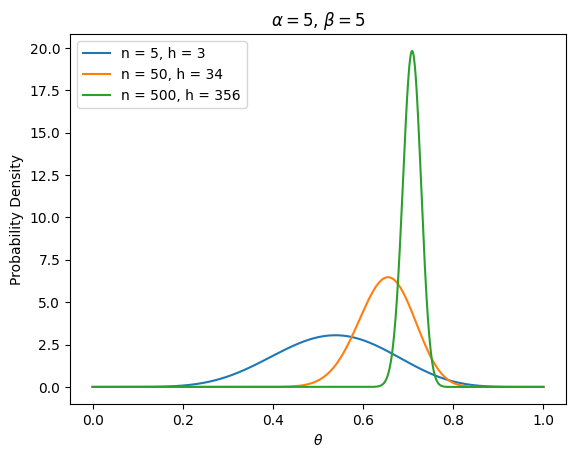

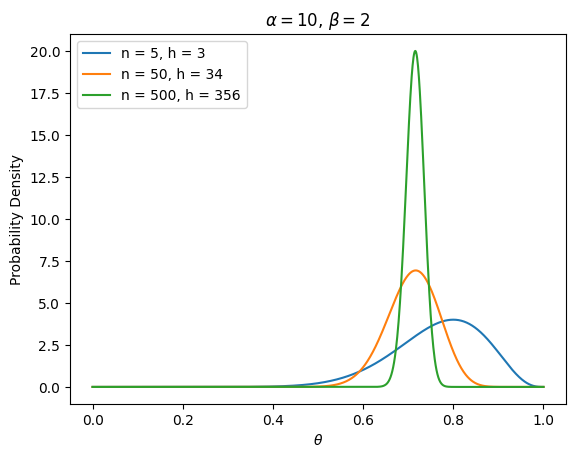

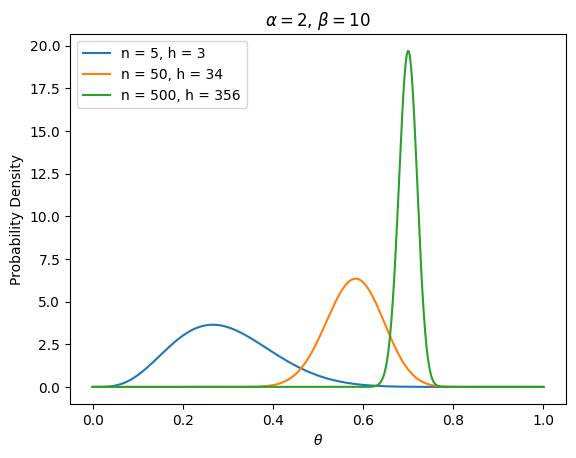

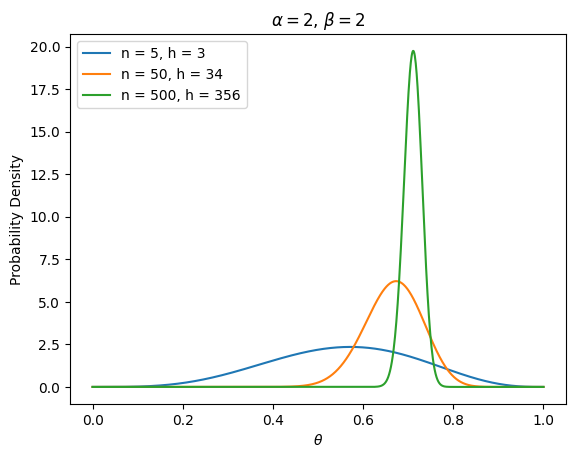

In [150]:
prior_arr = [[1,1],[5,5],[10,2],[2,10],[2,2]]
for priors in prior_arr:

    alpha = priors[0]
    beta = priors[1]

    for n in n_arr:
        h = np.sum(data[:n]).astype(int)
        posterior(alpha,beta,n,h)

    plt.title(rf'$\alpha = {alpha}$, $\beta = {beta}$')
    plt.show()

In [177]:
N=1000

data_x = np.random.rand(N)
data_y = np.random.rand(N)

index_in = []
index_out = []

for i in range(len(data_x)):
    r_i = np.sqrt(data_x[i]**2+data_y[i]**2)

    if r_i < 1:
        index_in.append(i)
    else:
        index_out.append(i)

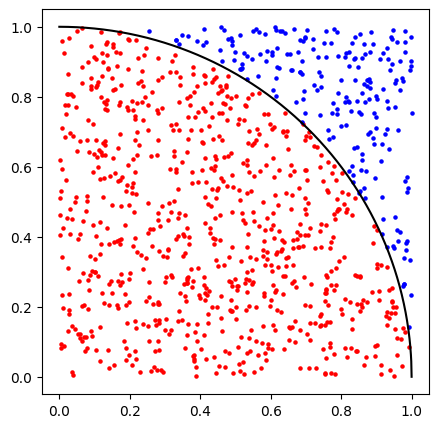

In [178]:
plt.figure(figsize=(5,5))

plt.scatter(data_x[index_in], data_y[index_in], color='red', s=5)
plt.scatter(data_x[index_out], data_y[index_out], color='blue', s=5)

x = np.linspace(0,1,1000)
plt.plot(x, np.sqrt(1-x**2), color='black')

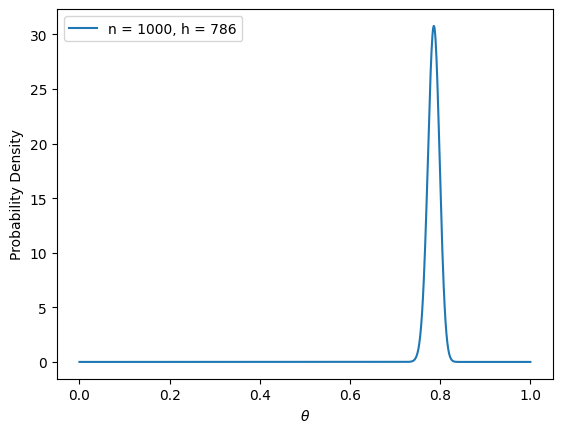

In [179]:
pi_est = posterior(1,1,N,len(index_in))

In [180]:
pi = pi_est[0][np.where(pi_est[1] == np.max(pi_est[1]))] * 4
pi

array([3.14314314])